In [ ]:
!pip install pandas matplotlib seaborn xgboost lightgbm scikit-learn contextily


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.8 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 11.8 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 12.2 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 4.8 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 13.0 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Style visualisasi agar notebook mudah dibaca
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [77]:
# ==========================================
# TAHAP 1: PREPROCESSING & GRID MAPPING
# ==========================================

def load_earthquake_data(file_path: str) -> pd.DataFrame:
    """Membaca data raw dari file CSV dan mengembalikan DataFrame yang sudah di-clean."""
    df = pd.read_csv(file_path)

    if 'type' in df.columns:
        df = df[df['type'] == 'earthquake'].copy()

    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.dropna(subset=['time', 'latitude', 'longitude', 'depth', 'mag']).reset_index(drop=True)

    return df


def apply_grid_mapping(df: pd.DataFrame, resolution: float = 1.0) -> pd.DataFrame:
    """Menambahkan kolom grid_id berdasarkan spatial binning 1x1 derajat."""
    df = df.copy()
    df['grid_lat'] = np.floor(df['latitude'] / resolution) * resolution
    df['grid_lon'] = np.floor(df['longitude'] / resolution) * resolution
    df['grid_id'] = df['grid_lat'].round(2).astype(str) + '_' + df['grid_lon'].round(2).astype(str)
    return df


def filter_dense_grids(df: pd.DataFrame, min_events: int = 10, window_days: int = 365) -> pd.DataFrame:
    """Saring grid yang memiliki minimal `min_events` dalam rentang waktu 365 hari."""
    valid_grids = []
    for grid_id, group in df.groupby('grid_id'):
        times = group['time'].sort_values().values
        if len(times) < min_events:
            continue

        start = 0
        for end in range(len(times)):
            while times[end] - times[start] > np.timedelta64(window_days, 'D'):
                start += 1
            if (end - start + 1) >= min_events:
                valid_grids.append(grid_id)
                break

    return df[df['grid_id'].isin(valid_grids)].copy()


file_path = 'query_global.csv'
df_raw = load_earthquake_data(file_path)
df_processed = apply_grid_mapping(df_raw, resolution=1.0)
df_processed = filter_dense_grids(df_processed, min_events=10, window_days=365)

print('Jumlah baris setelah load:', len(df_raw))
print('Jumlah grid spasial unik setelah filter:', df_processed['grid_id'].nunique())
print('Jumlah baris setelah filter:', len(df_processed))
df_processed.head()

Jumlah baris setelah load: 11799
Jumlah grid spasial unik setelah filter: 235
Jumlah baris setelah filter: 7242


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,horizontalError,depthError,magError,magNst,status,locationSource,magSource,grid_lat,grid_lon,grid_id
0,2026-06-10 04:30:32.974000+00:00,-19.9844,-177.5271,566.7700,4.8,mb,36.0,95.0,4.567,0.52,...,12.44,10.685000,0.109,26.0,reviewed,us,us,-20.0,-178.0,-20.0_-178.0
1,2026-06-10 04:05:46.467000+00:00,31.5110,-104.0120,7.2661,2.6,ml,7.0,132.0,0.000,0.20,...,0.00,3.988717,0.200,6.0,automatic,tx,tx,31.0,-105.0,31.0_-105.0
2,2026-06-10 03:45:49.904000+00:00,32.3050,-101.0390,2.5581,2.6,ml,51.0,73.0,0.200,0.40,...,0.00,0.968239,0.100,37.0,automatic,tx,tx,32.0,-102.0,32.0_-102.0
4,2026-06-10 02:55:55.627000+00:00,52.2140,-173.1790,5.0000,3.6,ml,33.0,188.0,0.600,0.70,...,9.50,0.000000,0.200,25.0,reviewed,ak,ak,52.0,-174.0,52.0_-174.0
5,2026-06-10 01:54:24.466000+00:00,5.6970,125.1975,89.6050,5.0,mb,52.0,101.0,1.415,1.16,...,9.14,6.893000,0.081,50.0,reviewed,us,us,5.0,125.0,5.0_125.0


In [86]:
# ==========================================
# TAHAP 2: FEATURE ENGINEERING PER GRID
# ==========================================

def magnitude_to_energy(magnitude: pd.Series) -> pd.Series:
    """Konversi magnitudo ke energi seismik (Joule)."""
    return 10 ** (4.8 + 1.5 * magnitude)


def generate_features_and_target(group: pd.DataFrame, sig_mag_threshold: float = 4.0) -> pd.DataFrame:
    """Menghasilkan fitur akumulasi dan target waktu sampai gempa signifikan berikutnya."""
    group = group.sort_values('time').copy()
    group['energy'] = magnitude_to_energy(group['mag'])
    group = group.set_index('time')

    group['energy_accum_7d'] = group['energy'].rolling('7D', closed='left').sum().values
    group['energy_accum_30d'] = group['energy'].rolling('30D', closed='left').sum().values
    group['energy_accum_90d'] = group['energy'].rolling('90D', closed='left').sum().values

    group['is_small_eq'] = (group['mag'] < 4.5).astype(float)
    group['small_eq_freq_30d'] = group['is_small_eq'].rolling('30D', closed='left').sum().values

    group = group.reset_index()

    sig_times = group.loc[group['mag'] >= sig_mag_threshold, 'time'].values
    if len(sig_times) == 0:
        group['days_until_next_earthquake'] = np.nan
    else:
        current_times = group['time'].values
        next_indices = np.searchsorted(sig_times, current_times, side='right')
        next_sig_times = [sig_times[idx] if idx < len(sig_times) else np.datetime64('NaT') for idx in next_indices]
        group['days_until_next_earthquake'] = (np.array(next_sig_times) - current_times) / np.timedelta64(1, 'D')

    return group


df_features = df_processed.groupby('grid_id', group_keys=False).apply(generate_features_and_target)
print('Jumlah baris setelah feature engineering:', len(df_features))
df_features[['grid_id', 'time', 'mag', 'energy_accum_7d', 'energy_accum_30d', 'energy_accum_90d', 'small_eq_freq_30d', 'days_until_next_earthquake']].head(10)

MAX_HARI_SUSULAN = 3.0
df_aftershock_only = df_features[df_features['days_until_next_earthquake'] <= MAX_HARI_SUSULAN].copy()
print(f"Total data modeling global: {len(df_features)}")
print(f"Total data setelah dikunci khusus gempa susulan: {len(df_aftershock_only)}")

Jumlah baris setelah feature engineering: 7242
Total data modeling global: 7242
Total data setelah dikunci khusus gempa susulan: 2240


/tmp/ipykernel_161211/1360050374.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_features = df_processed.groupby('grid_id', group_keys=False).apply(generate_features_and_target)


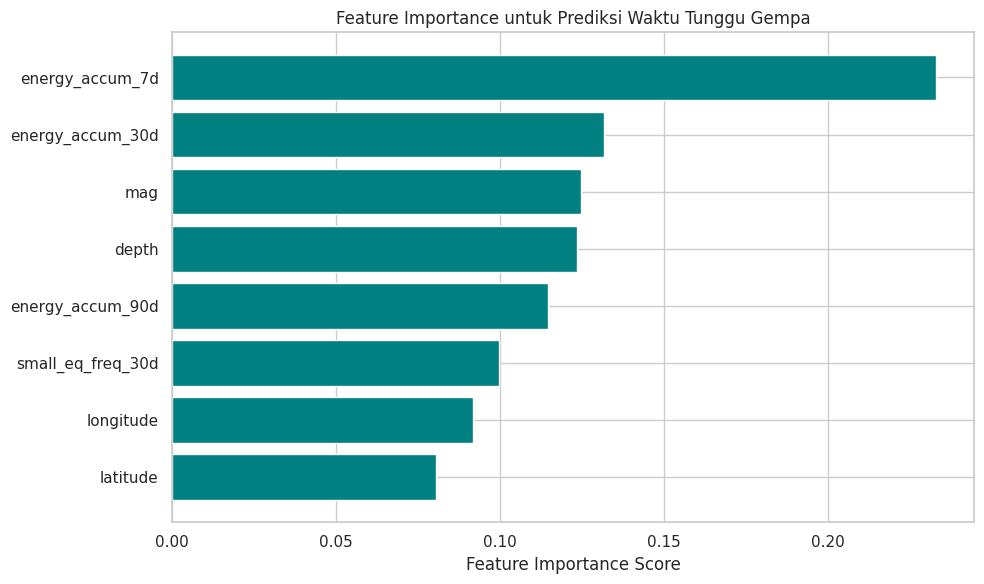

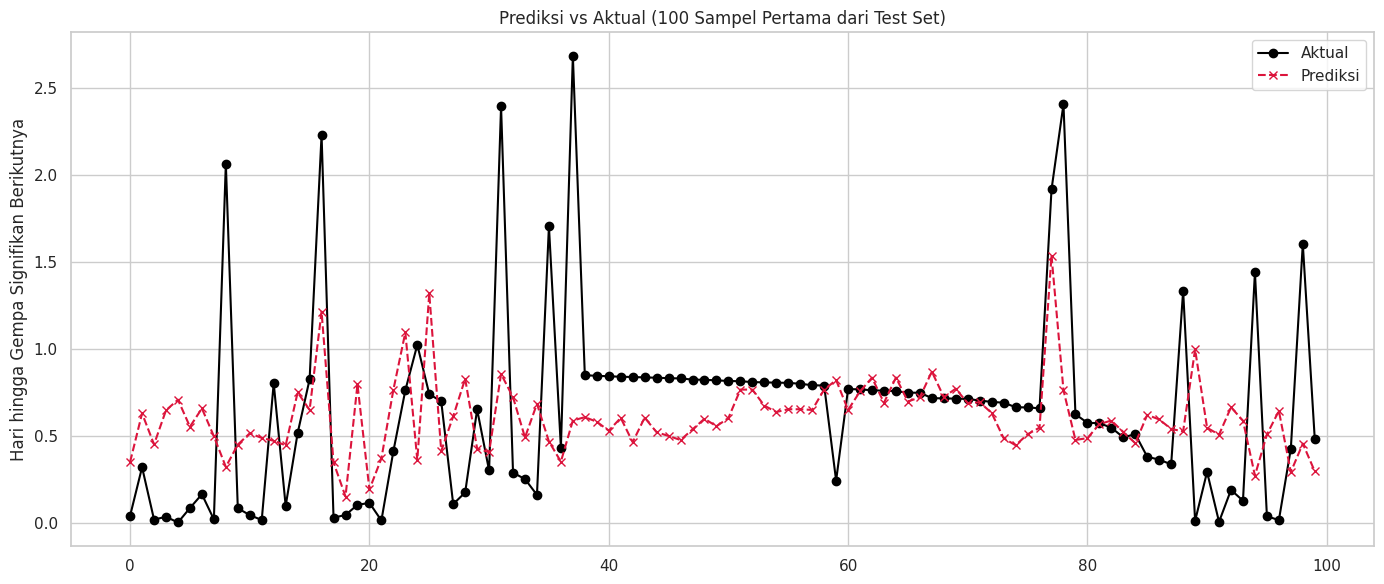

In [89]:
# ==========================================
# VISUALISASI: FEATURE IMPORTANCE DAN PREDIKSI
# ==========================================
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(np.array(FEATURE_COLUMNS)[sorted_idx], feature_importances[sorted_idx], color='teal')
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance untuk Prediksi Waktu Tunggu Gempa')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(y_test.values[:100], label='Aktual', color='black', marker='o')
plt.plot(results['y_pred'][:100], label='Prediksi', color='crimson', linestyle='--', marker='x')
plt.ylabel('Hari hingga Gempa Signifikan Berikutnya')
plt.title('Prediksi vs Aktual (100 Sampel Pertama dari Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [90]:

# ==========================================
# ANALISIS DETAIL HASIL PREDIKSI
# ==========================================

print("=== TARGET STATS ===")
print(f"Min: {y_test.min():.2f} hari")
print(f"Mean: {y_test.mean():.2f} hari")
print(f"Median: {y_test.median():.2f} hari")
print(f"Max: {y_test.max():.2f} hari")
print(f"Std Dev: {y_test.std():.2f} hari")

print("\n=== MODEL PERFORMANCE ===")
print(f"MAE: {results['mae']:.2f} hari (rata-rata error)")
print(f"RMSE: {results['rmse']:.2f} hari (penalti error besar)")
print(f"R² Score: {results['r2']:.4f} (0-1 scale, lebih besar lebih baik)")
print(f"Error % dari mean: {(results['mae'] / y_test.mean()) * 100:.1f}%")

print("\n=== PREDIKSI SAMPLE (10 pertama) ===")
for i in range(min(10, len(y_test))):
    actual = y_test.iloc[i]
    pred = results['y_pred'][i]
    error = abs(actual - pred)
    print(f"Sample {i+1}: Actual={actual:.1f}d | Pred={pred:.1f}d | Error={error:.1f}d")


=== TARGET STATS ===
Min: 0.00 hari
Mean: 0.68 hari
Median: 0.38 hari
Max: 2.97 hari
Std Dev: 0.78 hari

=== MODEL PERFORMANCE ===
MAE: 0.56 hari (rata-rata error)
RMSE: 0.76 hari (penalti error besar)
R² Score: 0.0451 (0-1 scale, lebih besar lebih baik)
Error % dari mean: 81.4%

=== PREDIKSI SAMPLE (10 pertama) ===
Sample 1: Actual=0.0d | Pred=0.3d | Error=0.3d
Sample 2: Actual=0.3d | Pred=0.6d | Error=0.3d
Sample 3: Actual=0.0d | Pred=0.5d | Error=0.4d
Sample 4: Actual=0.0d | Pred=0.6d | Error=0.6d
Sample 5: Actual=0.0d | Pred=0.7d | Error=0.7d
Sample 6: Actual=0.1d | Pred=0.6d | Error=0.5d
Sample 7: Actual=0.2d | Pred=0.7d | Error=0.5d
Sample 8: Actual=0.0d | Pred=0.5d | Error=0.5d
Sample 9: Actual=2.1d | Pred=0.3d | Error=1.7d
Sample 10: Actual=0.1d | Pred=0.4d | Error=0.4d


In [91]:
# Hitung selisih mutlak dalam satuan hari
errors = np.abs(y_test - results['y_pred'])

# Hitung persentase tebakan yang sangat akurat (toleransi kurang dari 1 atau 2 hari)
accurate_1d = np.mean(errors <= 1.0) * 100
accurate_2d = np.mean(errors <= 2.0) * 100

print("=== EVALUASI REALISTIS GEOLOGI ===")
print(f"Persentase Prediksi Akurat (Meleset < 1 Hari): {accurate_1d:.2f}%")
print(f"Persentase Prediksi Akurat (Meleset < 2 Hari): {accurate_2d:.2f}%")

=== EVALUASI REALISTIS GEOLOGI ===
Persentase Prediksi Akurat (Meleset < 1 Hari): 85.04%
Persentase Prediksi Akurat (Meleset < 2 Hari): 96.65%


In [96]:
# 1. Buat DataFrame khusus hasil prediksi pada Test Set
df_result = df_ml.iloc[X_test.index].copy()
df_result['predicted_days_until_gempa'] = results['y_pred']

# 2. Filter: Ambil hanya grid yang diprediksi akan gempa dalam waktu dekat (misal <= 2 hari)
THRESHOLD_SIAGA = 0.3
df_siaga = df_result[df_result['predicted_days_until_gempa'] <= THRESHOLD_SIAGA].copy()

# 3. Urutkan dari yang paling cepat/paling mendekati hari-H gempa
df_siaga_sorted = df_siaga.sort_values(by='predicted_days_until_gempa')

print(f"=== DAFTAR GRID STATUS SIAGA (Gempa < {THRESHOLD_SIAGA} Hari) ===")
print(df_siaga_sorted[['grid_id', 'latitude', 'longitude', 'mag', 'predicted_days_until_gempa']].drop_duplicates(subset=['grid_id']).head(10))

=== DAFTAR GRID STATUS SIAGA (Gempa < 0.3 Hari) ===
          grid_id  latitude  longitude  mag  predicted_days_until_gempa
1948   16.0_-99.0   16.4698   -98.0183  5.5                    0.000000
1977    7.0_126.0    7.5271   126.7728  5.5                    0.000000
2018   51.0_179.0   51.0530   179.2934  5.8                    0.011345
2220    4.0_125.0    4.9191   125.3094  5.6                    0.027732
2000   -3.0_147.0   -2.8761   147.7722  5.6                    0.041880
2090  -18.0_168.0  -17.8109   168.8929  4.8                    0.096249
2164   16.0_119.0   16.3879   119.2212  4.6                    0.114444
1975   52.0_176.0   52.3404   176.5321  5.8                    0.127592
2194    5.0_125.0    5.5918   125.0469  7.8                    0.131325
1810   52.0_161.0   52.8044   161.1071  5.3                    0.151335


/tmp/ipykernel_161211/2731026841.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([f"{tick:.1f} hari" for tick in cbar.get_ticks()])


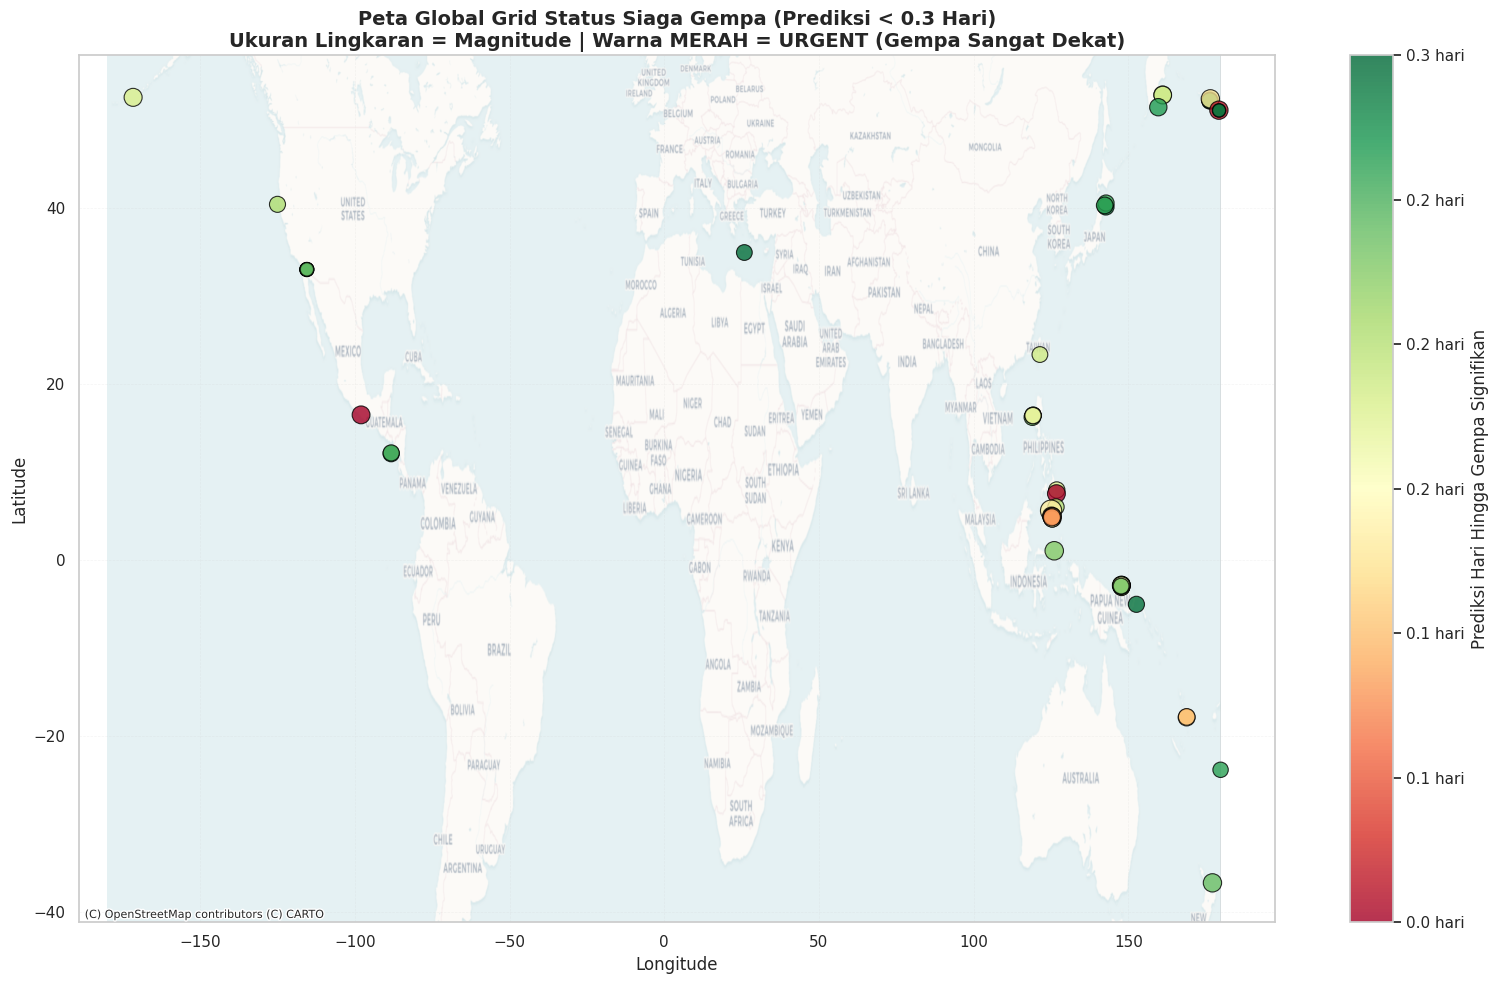


=== TOP 10 GRID PALING RAWAN (Prediksi < 0.3 Hari) ===
    grid_id  latitude  longitude  mag  predicted_days_until_gempa
 16.0_-99.0   16.4698   -98.0183  5.5                    0.000000
  7.0_126.0    7.5271   126.7728  5.5                    0.000000
 51.0_179.0   51.0530   179.2934  5.8                    0.011345
  4.0_125.0    4.9191   125.3094  5.6                    0.027732
 -3.0_147.0   -2.8761   147.7722  5.6                    0.041880
-18.0_168.0  -17.8109   168.8929  4.8                    0.096249
 16.0_119.0   16.3879   119.2212  4.6                    0.114444
 52.0_176.0   52.3404   176.5321  5.8                    0.127592
  5.0_125.0    5.5918   125.0469  7.8                    0.131325
 52.0_161.0   52.8044   161.1071  5.3                    0.151335


In [97]:
import contextily as ctx

# Visualisasi dengan matplotlib scatter plot + peta background dengan batas negara
fig, ax = plt.subplots(figsize=(16, 10))

# Plot semua grid dengan warna berdasarkan prediksi hari
# Kita kunci vmin=0 (paling dekat/merah) dan vmax=THRESHOLD_SIAGA (paling jauh/hijau)
scatter = ax.scatter(
    df_siaga['longitude'],
    df_siaga['latitude'],
    c=df_siaga['predicted_days_until_gempa'],
    s=df_siaga['mag'] * 30,         # Ukuran point = magnitude
    cmap='RdYlGn',                  # Urutan: Rendah (Merah) -> Sedang (Kuning) -> Tinggi (Hijau)
    vmin=0,                         # Mengunci warna MERAH pekat untuk 0 hari (Urgent)
    vmax=THRESHOLD_SIAGA,           # Mengunci warna HIJAU pekat untuk hari maksimal (Aman)
    alpha=0.8,
    edgecolors='black',
    linewidth=0.8,
    zorder=5                        # Memastikan titik berada DI ATAS map background
)

# Plot background peta dunia dengan CartoDB.Voyager (menampilkan batas negara/wilayah)
# Ditulis setelah scatter atau pastikan zorder scatter lebih tinggi agar tidak tertutup peta
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Voyager, zoom=3, alpha=0.6)

# Pengaturan tambahan untuk colorbar agar informasinya tidak membingungkan
cbar = plt.colorbar(scatter, ax=ax, label='Prediksi Hari Hingga Gempa Signifikan')
cbar.ax.set_yticklabels([f"{tick:.1f} hari" for tick in cbar.get_ticks()])

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Peta Global Grid Status Siaga Gempa (Prediksi < {THRESHOLD_SIAGA} Hari)\nUkuran Lingkaran = Magnitude | Warna MERAH = URGENT (Gempa Sangat Dekat)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Simpan gambar kualitas tinggi untuk laporan kuliah
plt.savefig('peta_siaga_gempa_global_fixed.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Tampilkan informasi tabel top 10 grid paling rawan
print(f"\n=== TOP 10 GRID PALING RAWAN (Prediksi < {THRESHOLD_SIAGA} Hari) ===")
top_grids = df_siaga_sorted.drop_duplicates(subset=['grid_id']).head(10)[['grid_id', 'latitude', 'longitude', 'mag', 'predicted_days_until_gempa']]
print(top_grids.to_string(index=False))